In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/raw/euskadi/listings.csv.gz")

## 2. Básico

In [3]:
print(df.shape)

(6248, 90)


90 columnas (6248 filas): mismo esquema exacto de columnas que Sevilla, pero con un reparto de tipos algo distinto (42 `float64`, 30 `object`, 18 `int64` frente a 36/30/24 en Sevilla) — la diferencia está en columnas que aquí tienen más nulos y `pandas` las infiere como `float64` en vez de `int64`.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].index.tolist()

['neighborhood_overview',
 'host_since',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_thumbnail_url',
 'host_neighbourhood',
 'host_total_listings_count',
 'host_verifications',
 'neighbourhood',
 'calendar_updated',
 'instant_bookable']

**Las mismas 12 columnas que en las otras cinco ciudades están completamente vacías** (100% nulas): metadatos que Inside Airbnb deja de publicar en todos los datasets recientes (`host_response_time`, `host_acceptance_rate`, `neighborhood_overview`, `instant_bookable`...).

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,6248.0,6.701543e+17,6.256120e+17,1.320680e+05,3.707324e+07,7.241552e+17,1.232613e+18,1.718896e+18
scrape_id,6248.0,2.026063e+13,0.000000e+00,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,6248.0,1.329129e+16,1.495128e+17,5.955000e+04,5.857252e+07,1.928748e+08,4.533825e+08,1.715812e+18
host_profile_id,6242.0,1.472420e+18,3.009603e+16,1.462508e+18,1.463094e+18,1.468217e+18,1.470017e+18,1.717190e+18
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,6242.0,7.083627e+00,3.795956e+00,0.000000e+00,4.000000e+00,8.000000e+00,1.000000e+01,1.600000e+01
hosts_time_as_user_months,6242.0,5.053829e+00,3.616487e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
hosts_time_as_host_years,6242.0,5.936879e+00,3.767373e+00,0.000000e+00,3.000000e+00,6.000000e+00,9.000000e+00,1.500000e+01
hosts_time_as_host_months,6242.0,4.665972e+00,3.751762e+00,0.000000e+00,1.000000e+00,4.000000e+00,8.000000e+00,1.100000e+01


Igual que en las otras cinco ciudades: `price` llega como texto (`"$483.00"`, no `483.00`), y aparecen los mismos huecos de `bathrooms`/`bedrooms`/`beds` que hay que resolver.

## 3. Corrección de tipos

#### `price`

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].describe()

count    5676.000000
mean      264.625157
std       276.032078
min         4.840000
25%       130.500000
50%       196.000000
75%       315.542500
max      9999.000000
Name: price, dtype: float64

#### Fechas

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)

#### Flags `t`/`f`

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}))

#### `host_profile_id`

In [9]:
df["host_profile_id"] = df["host_profile_id"].astype("Int64")

#### Provincias y municipios: doble codificación a corregir

In [10]:
df[["neighbourhood_group_cleansed", "neighbourhood_cleansed"]].drop_duplicates().head(6)

,neighbourhood_group_cleansed,neighbourhood_cleansed
0,GuipÃºzcoa,Donostia-San SebastiÃ¡n
3,Vizcaya,Bilbao
4,GuipÃºzcoa,Oiartzun
6,GuipÃºzcoa,Mutriku
7,Vizcaya,Durango
9,Vizcaya,AbadiÃ±o


`neighbourhood_group_cleansed` sale como `GuipÃºzcoa` / `Ã\x81lava` en vez de `Guipúzcoa` / `Álava`: un mojibake clásico (texto en UTF-8 decodificado una vez de más como Latin-1). Se repite en 20 de los 207 municipios (`Donostia-San SebastiÃ¡n`, `AbadiÃ±o`, `OÃ±ati`...). Se corrige re-codificando a Latin-1 y decodificando de vuelta a UTF-8 — a diferencia de Valencia/Sevilla, aquí sí hace falta normalizar antes de poder usar estos nombres.

In [11]:
def fix_mojibake(s):
    if isinstance(s, str):
        try:
            return s.encode("latin-1").decode("utf-8")
        except (UnicodeDecodeError, UnicodeEncodeError):
            return s
    return s


df["neighbourhood_cleansed"] = df["neighbourhood_cleansed"].apply(fix_mojibake)
df["neighbourhood_group_cleansed"] = df["neighbourhood_group_cleansed"].apply(fix_mojibake)
df["neighbourhood_group_cleansed"].unique()

array(['Guipúzcoa', 'Vizcaya', 'Álava'], dtype=object)

Arreglado: `Guipúzcoa`, `Vizcaya`, `Álava`. Se comprueba que no queda ningún resto (`Ã` suelta) en los 207 municipios.

In [12]:
sum("Ã" in str(m) for m in df["neighbourhood_cleansed"].unique())

0

0 residuos. Quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` (formato específico, se revisan solo si hace falta en la sección de outliers).

## 4. Nulos

In [13]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct.head(20)

neighbourhood                100.00
host_neighbourhood           100.00
host_total_listings_count    100.00
host_acceptance_rate         100.00
host_response_rate           100.00
host_response_time           100.00
host_verifications           100.00
host_since                   100.00
host_thumbnail_url           100.00
calendar_updated             100.00
instant_bookable             100.00
neighborhood_overview        100.00
host_about                    52.54
host_location                 28.71
bathrooms                     15.54
bedrooms                      14.85
license                       11.81
beds                          11.54
first_review                  10.13
review_scores_location        10.13
dtype: float64

### 4.1 Estrategia

#### Columnas 100% vacías

In [14]:
empty_cols = [
    "neighborhood_overview", "host_since", "host_response_time", "host_response_rate",
    "host_acceptance_rate", "host_thumbnail_url", "host_neighbourhood", "host_total_listings_count",
    "host_verifications", "neighbourhood", "calendar_updated", "instant_bookable",
]
df = df.drop(columns=empty_cols)
df.shape

(6248, 78)

#### `bathrooms`

In [15]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
half_mask = (
    df["bathrooms"].isnull()
    & df["bathrooms_text"].str.contains("half", case=False, na=False)
    & bathrooms_extracted.isnull()
)
bathrooms_extracted.loc[half_mask] = 0.5
print(df["bathrooms"].isnull().sum(), "nulos antes;", half_mask.sum(), "de ellos 'half-bath' sin dígito")
df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
df["bathrooms"].isnull().sum()

971 nulos antes; 12 de ellos 'half-bath' sin dígito


np.int64(20)

De los 971 nulos, 939 se recuperan desde `bathrooms_text` (incluyendo 12 casos de `"Half-bath"` sin dígito, reinterpretados como 0.5). Quedan **20 filas** sin ningún dato de baños (ni siquiera `bathrooms_text`) — a diferencia de Sevilla, donde la recuperación fue del 100%. Esas 20 se resuelven más adelante junto con `bedrooms`/`beds`.

#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_*`)

In [16]:
mask = df["review_scores_rating"].isnull()
mask.sum(), df.loc[mask, "first_review"].isnull().sum(), df["reviews_per_month"].isnull().sum()

(np.int64(633), np.int64(633), np.int64(633))

Se confirma: los 633 anuncios sin `review_scores_rating` son exactamente los mismos sin `first_review` y sin `reviews_per_month` — anuncios sin reservas reseñadas todavía, no un problema de captura. `reviews_per_month` se imputa a 0. `first_review`/`last_review`/`review_scores_*` se dejan como `NaT`/`NaN`, informativamente vacíos.

In [17]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

In [18]:
df["has_license"] = df["license"].notna()
df["has_license"].value_counts(normalize=True).mul(100).round(2)

has_license
True     88.19
False    11.81
Name: proportion, dtype: float64

88.19% de los anuncios tiene licencia registrada: por debajo de Málaga (92.69%), Sevilla (93.71%) y sobre todo Mallorca (99.57%), pero muy por encima de Madrid (64.52%) — un nivel de cumplimiento intermedio.

In [19]:
df["license"] = df["license"].fillna("Sin licencia")

#### `price`

In [20]:
df = df.dropna(subset=["price"])
df.shape

(5676, 79)

572 filas descartadas por no tener `price` (9.15% del total): la cuarta tasa más baja de las seis ciudades, después de Sevilla (7.29%), Valencia (7.44%) y Málaga (8.52%), y muy lejos del 25.38% de Mallorca.

#### Columnas de bajo volumen (host, estancia)

In [21]:
low_vol_cols = [
    "host_identity_verified", "host_has_profile_pic", "host_profile_id", "host_listings_count",
    "host_picture_url", "host_is_superhost", "hosts_time_as_host_months", "hosts_time_as_host_years",
    "hosts_time_as_user_months", "hosts_time_as_user_years", "host_name", "host_profile_url",
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights", "maximum_nights",
]
mask_lowvol = df[low_vol_cols].isnull().any(axis=1)
mask_lowvol.sum()

np.int64(6)

In [22]:
df = df[~mask_lowvol]
df.shape

(5670, 79)

Solo 6 filas afectadas (0.07-0.11% de nulos cada una): 2 anuncios sin `minimum_nights`/`maximum_nights` y 4 con todo el bloque de host roto a la vez. Se descartan directamente, igual que en Sevilla.

#### `bedrooms` / `beds` / `bathrooms`

In [23]:
print(df.groupby("room_type")["bedrooms"].apply(lambda s: s.isnull().mean() * 100).round(1))

room_type
Entire home/apt     2.4
Hotel room          2.1
Private room       49.4
Shared room         0.0
Name: bedrooms, dtype: float64


Se imputa con la **mediana dentro de cada `room_type`**, la misma regla que en las otras cinco ciudades — incluidos ahora los 20 restantes de `bathrooms`.

In [24]:
for c in ["bedrooms", "beds", "bathrooms"]:
    df[c] = df.groupby("room_type")[c].transform(lambda s: s.fillna(s.median()))
df[["bedrooms", "beds", "bathrooms"]].isnull().sum()

bedrooms     0
beds         0
bathrooms    0
dtype: int64

In [25]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct.head(12)

host_about                     53.49
host_location                  29.01
review_scores_cleanliness       9.45
review_scores_value             9.45
review_scores_rating            9.45
review_scores_accuracy          9.45
review_scores_checkin           9.45
review_scores_communication     9.45
review_scores_location          9.45
first_review                    9.45
last_review                     9.45
description                     2.86
dtype: float64

Quedan sin tratar, a propósito: `review_scores_*`/`first_review`/`last_review` (informativamente vacíos), `host_about`/`host_location`/`description` (texto libre, no se usan como feature numérica).

## 5. Duplicados

In [26]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que la fila completa.

In [27]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

In [28]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
dups = df[df.duplicated(subset=dup_cols, keep=False)]
len(dups), dups.groupby(dup_cols).ngroups

(62, 21)

65 filas repartidas en 22 grupos: mismo patrón que en las otras ciudades, sobre todo pensiones/hostales/aparthoteles que registran cada habitación como un anuncio separado (p. ej. 7 filas de "Cama en habitación compartida. 10 personas.", mismo host y coordenadas, precios distintos).

In [29]:
cols_except_id = [c for c in df.columns if c != "id"]
df.duplicated(subset=cols_except_id, keep=False).sum()

np.int64(0)

#### Conclusión

0 filas duplicadas de fila completa, 0 `id` repetidos, y 0 filas idénticas en todo salvo `id`: **no hay ningún duplicado que eliminar**. Los 62 "duplicados lógicos" son habitaciones/anuncios reales distintos dentro del mismo alojamiento, con datos propios (precio, reseñas) en el resto de columnas. No se toca nada.

## 6. Variables Categóricas

In [30]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
len(cat_cols)

26

### 6.1 Cardinalidad: los mismos grupos que en las otras ciudades

### 6.2 Categóricas de baja cardinalidad

In [31]:
df["has_availability"].value_counts(dropna=False)

has_availability
True    5670
Name: count, dtype: int64

Tras la limpieza de filas anterior, `has_availability` queda **100% `True`**: totalmente constante, sin ninguna variación que aporte señal. Se elimina.

In [32]:
df = df.drop(columns=["has_availability"])

#### `source`

In [33]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        97.4
previous scrape     2.6
Name: proportion, dtype: float64

97.4% `city scrape` / 2.6% `previous scrape`, en línea con Sevilla (97.0%/3.0%) — la fracción de scrape antiguo es mínima en las seis ciudades.

#### `property_type`

In [34]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   3251
Private room in rental unit           489
Entire home                           307
Private room in home                  215
Room in hotel                         195
Entire cottage                        100
Entire condo                          100
Private room in hostel                 93
Entire serviced apartment              88
Private room in bed and breakfast      88
Private room in cottage                74
Private room in guesthouse             57
Room in boutique hotel                 54
Entire loft                            47
Entire villa                           36
Name: count, dtype: int64

61 categorías (más que las 42 de Sevilla): mayor diversidad de alojamiento rural/turístico (`Entire cottage`, `Private room in bed and breakfast`, `Private room in hostel`, `Private room in cottage`...), reflejo del turismo de caserío y agroturismo vasco. `Entire rental unit` sigue siendo la mayoría (57.3%), pero con menos concentración que en Sevilla (74.2%) o Málaga (73.4%).

#### `room_type`

In [35]:
df["room_type"].value_counts(normalize=True).mul(100).round(1)

room_type
Entire home/apt    73.4
Private room       25.0
Hotel room          0.8
Shared room         0.7
Name: proportion, dtype: float64

`Entire home/apt` domina (73.4%), `Private room` es la única categoría secundaria con peso real (25.0%). `Hotel room` (0.8%) y `Shared room` (0.7%) son marginales.

#### `neighbourhood_group_cleansed` (provincia) / `neighbourhood_cleansed` (municipio)

In [36]:
df["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Vizcaya      3045
Guipúzcoa    2221
Álava         404
Name: count, dtype: int64

Vizcaya concentra el 53.7% del dataset, Guipúzcoa el 39.2% y Álava solo el 7.1% — refleja que Vitoria-Gasteiz, pese a ser la capital autonómica y la ciudad más poblada de las tres, tiene muchísimo menos peso turístico en Airbnb que Bilbao o Donostia.

In [37]:
df["neighbourhood_cleansed"].value_counts().head(10)

neighbourhood_cleansed
Bilbao                    1492
Donostia-San Sebastián    1410
Bermeo                     178
Vitoria-Gasteiz            164
Zarautz                    149
Getxo                      126
Hondarribia                115
Barakaldo                   80
Mundaka                     73
Sopelana                    61
Name: count, dtype: int64

Bilbao (1492) y Donostia-San Sebastián (1410) son los dos únicos municipios con volumen realmente grande, muy cerca entre sí (en los datos crudos originales Donostia iba ligeramente por delante; tras la limpieza de filas Bilbao queda arriba); el resto son pueblos costeros/rurales muy por debajo (Bermeo, Vitoria-Gasteiz, Zarautz, Hondarribia...).

#### Columnas booleanas

In [38]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c)
    print(df[c].value_counts(normalize=True).mul(100).round(1))
    print()

host_is_superhost
host_is_superhost
False    59.1
True     40.9
Name: proportion, dtype: float64

host_has_profile_pic
host_has_profile_pic
True     95.9
False     4.1
Name: proportion, dtype: float64

host_identity_verified
host_identity_verified
True     98.9
False     1.1
Name: proportion, dtype: float64

has_license
has_license
True     89.3
False    10.7
Name: proportion, dtype: float64



`host_has_profile_pic` (95.9%) y `host_identity_verified` (98.9%) casi siempre a `True`, poca variabilidad. `host_is_superhost` (40.9%) es la más equilibrada de las cuatro.

## 7. Numéricas

In [39]:
num_cols = df.select_dtypes(include="number").columns
len(num_cols)

49

### 7.1 Identificadores/geográficas vs. variables de interés

### 7.2 Familias de variables redundantes

In [40]:
nights_family = [
    "minimum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
]
df[nights_family].corr()

,minimum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm
minimum_nights,1.000000,1.000000,0.729510,-0.028930,-0.072902,0.956679,-0.057569
minimum_minimum_nights,1.000000,1.000000,0.729510,-0.028930,-0.072902,0.956679,-0.057569
maximum_minimum_nights,0.729510,0.729510,1.000000,-0.030273,-0.023529,0.844762,-0.027455
minimum_maximum_nights,-0.028930,-0.028930,-0.030273,1.000000,0.786965,-0.018873,0.908155
maximum_maximum_nights,-0.072902,-0.072902,-0.023529,0.786965,1.000000,-0.050851,0.946757
minimum_nights_avg_ntm,0.956679,0.956679,0.844762,-0.018873,-0.050851,1.000000,-0.042345
maximum_nights_avg_ntm,-0.057569,-0.057569,-0.027455,0.908155,0.946757,-0.042345,1.000000


`minimum_nights` y `minimum_minimum_nights` correlacionan **1.00**, literalmente el mismo dato, igual que en las otras cinco ciudades. Se sigue usando `minimum_nights`.

In [41]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365", "availability_eoy"]
df[avail_family].corr()

,availability_30,availability_60,availability_90,availability_365,availability_eoy
availability_30,1.000000,0.909763,0.827652,0.257313,0.480603
availability_60,0.909763,1.000000,0.917458,0.294759,0.543324
availability_90,0.827652,0.917458,1.000000,0.392836,0.696678
availability_365,0.257313,0.294759,0.392836,1.000000,0.743926
availability_eoy,0.480603,0.543324,0.696678,0.743926,1.000000


Solape moderado (0.26 a 0.92). Se sigue usando `availability_365`, la más completa.

### 7.3 Comprobación: `hosts_time_as_*` y `host_listings_count`

In [42]:
hosts_time_cols = ["hosts_time_as_user_years", "hosts_time_as_user_months", "hosts_time_as_host_years", "hosts_time_as_host_months"]
df[hosts_time_cols].isnull().sum()

hosts_time_as_user_years     0
hosts_time_as_user_months    0
hosts_time_as_host_years     0
hosts_time_as_host_months    0
dtype: int64

Sin nulos, rangos razonables: son campos derivados que sobrevivieron aunque `host_since` esté vacía (una de las 12 columnas eliminadas).

In [43]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.340304
calculated_host_listings_count,0.340304,1.000000


Correlación baja (0.34): `host_listings_count` (autodeclarado por el host) y `calculated_host_listings_count` (recalculado por Inside Airbnb a partir del scrape actual) divergen más aquí que en Sevilla (0.56) — probablemente por el peso de gestoras que operan en varias provincias a la vez.

### 7.4 Variables clave: estadísticos y asimetría

In [44]:
num_vars = [
    "price", "accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights", "maximum_nights",
    "availability_365", "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "calculated_host_listings_count",
]
df[num_vars].skew().sort_values(ascending=False)

price                             11.239910
minimum_nights                     6.682820
reviews_per_month                  5.115863
bathrooms                          5.022300
number_of_reviews                  3.404132
calculated_host_listings_count     3.323880
beds                               3.102602
bedrooms                           2.831497
accommodates                       2.097633
maximum_nights                    -0.072244
availability_365                  -0.115984
review_scores_rating              -4.048212
dtype: float64

`price` tiene una asimetría de 11.2 — más moderada que Sevilla (18.2) o Valencia (20.1), coherente con no tener (todavía) un artefacto de precio extremo como Mallorca.

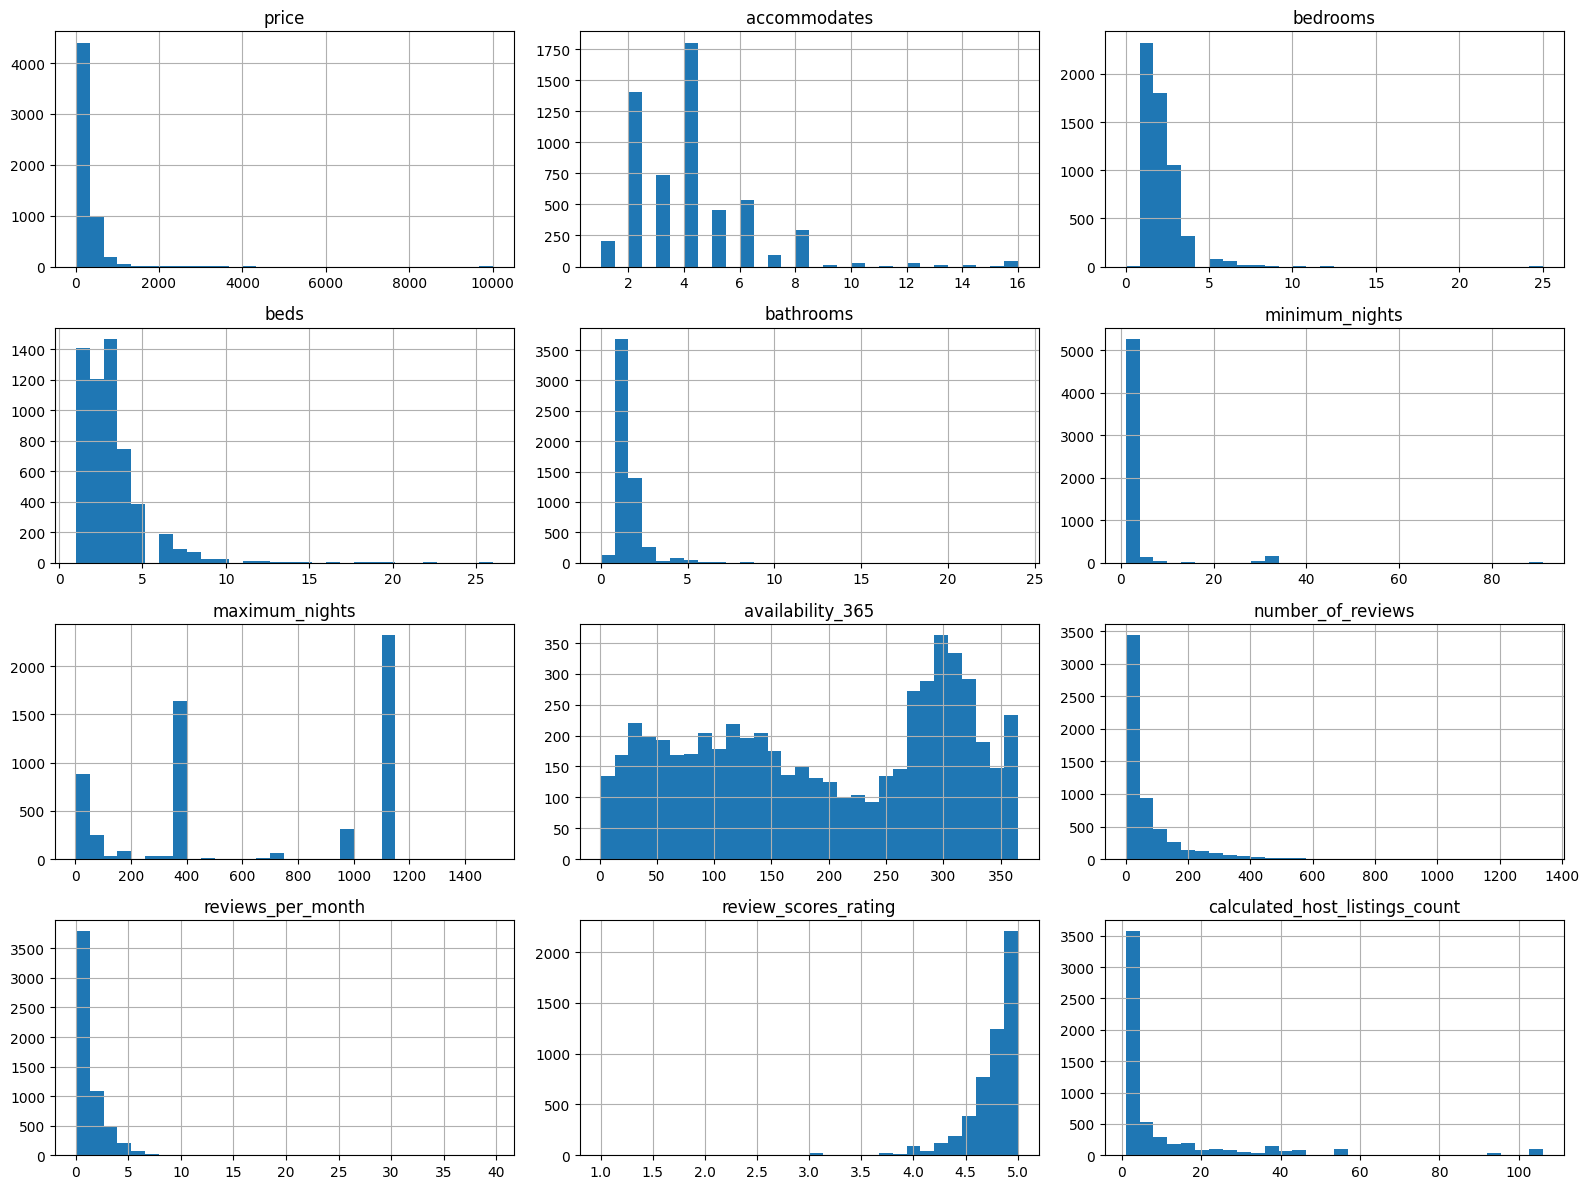

In [45]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()
plt.show()

## 8. Outliers

### 8.1 Método: rango intercuartílico (IQR)

In [46]:
outlier_summary = []
for c in num_vars[1:]:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    pct = ((s < lo) | (s > hi)).mean() * 100
    outlier_summary.append((c, round(pct, 1)))
pd.DataFrame(outlier_summary, columns=["variable", "pct_outliers"]).sort_values("pct_outliers", ascending=False)

,variable,pct_outliers
10,calculated_host_listings_count,14.5
7,number_of_reviews,9.1
4,minimum_nights,7.2
8,reviews_per_month,5.5
9,review_scores_rating,5.4
2,beds,3.2
3,bathrooms,3.0
0,accommodates,2.3
1,bedrooms,0.7
5,maximum_nights,0.0


`calculated_host_listings_count` (14.5%) encabeza la lista, patrón conocido de las otras ciudades — gestoras profesionales con muchos anuncios. `number_of_reviews` (9.1%) y `minimum_nights` (7.2%) le siguen.

### 8.2 La cola alta de `price`: sin artefacto limpio, pero con una historia real detrás

In [47]:
df.sort_values("price", ascending=False)[["name", "host_name", "room_type", "accommodates", "price", "number_of_reviews", "minimum_nights", "availability_365"]].head(15)

,name,host_name,room_type,accommodates,price,number_of_reviews,minimum_nights,availability_365
2871,Habitación doble con supletoria niño en Sondika,Jose,Private room,2,9999.00,3,1.0,13
5211,Final Europa League San Mames.,Ibai,Private room,6,4222.00,0,1.0,365
5240,Bajo con jardín,Diana,Entire home/apt,4,4049.00,0,1.0,364
4749,Basurto San Mamés Pintxos by NSB,Edortxa,Entire home/apt,4,3483.00,3,1.0,365
5239,Europa League Final,Aitor,Entire home/apt,4,3424.00,0,1.0,365
1348,Crown of La Concha Beach by DonosRent,Natalia,Entire home/apt,8,3301.00,18,3.0,352
5160,Villa Lycka by SanSe Holidays,SanSe Holidays Tourist Apts In San Sebastián,Entire home/apt,10,2919.50,0,31.0,157
6243,Villa Ocean Breeze | Atlantic Realty,AtlanticRealty,Entire home/apt,14,2856.42,0,31.0,362
5236,Bilbao Final Europa League,Oskar,Entire home/apt,4,2738.82,0,1.0,365
488,La Concha Beach Deluxe by DonosRent,Natalia,Entire home/apt,8,2354.67,55,3.0,318


No hay un salto brusco ni un grupo de valores idénticos: la cola baja de forma prácticamente continua. Pero dos fenómenos distintos explican los precios más altos:

1. **La final de la Europa League en San Mamés (Bilbao)**: 12 anuncios mencionan explícitamente "Final Europa League"/"UEFA Final" en el nombre, repriceados para esa semana concreta. Su mediana de precio (405€) más que duplica la mediana general (196€), y varios llegan a 2.700-4.222€ por noche — demanda puntual de un evento, no un error de captura.
2. **Precio disuasorio puntual**: "Habitación doble con supletoria niño en Sondika" a 9.999€/noche, `Private room` para 2 personas, con 3 reseñas (probablemente a un precio muy distinto en el pasado) y disponible solo 13 noches al año — el patrón típico de un precio fijado para bloquear reservas, no una tarifa real.

Ninguno de los dos es un error de limpieza: son datos de mercado genuinos con contexto propio. No se descarta ninguna fila por esto.

### 8.3 Caso concreto: un error de captura en `bedrooms`/`beds`/`bathrooms`

In [48]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "bathrooms", "price", "number_of_reviews"]
error_mask = (df["bedrooms"] >= 8) & (df["bedrooms"] == df["beds"]) & (df["accommodates"] < df["bedrooms"])
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price,number_of_reviews
2409,Habitación individual con cocina y baño,Private room,1,25.0,25.0,24.0,76.0,25


"Habitación individual con cocina y baño": `Private room` para 1 persona con `bedrooms = beds = 25` y `bathrooms = 24`. A diferencia del caso de Sevilla (donde `bathrooms` sí era plausible y se dejó tal cual), aquí las tres cifras son absurdas para una habitación individual — parecen las estadísticas de todo el edificio copiadas en una sola fila. Se corrigen las tres, reimputando con la misma regla de la sección 4 (mediana por `room_type`).

In [49]:
for c in ["bedrooms", "beds", "bathrooms"]:
    df.loc[error_mask, c] = df.groupby("room_type")[c].transform("median")[error_mask]
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price,number_of_reviews
2409,Habitación individual con cocina y baño,Private room,1,1.0,1.0,1.0,76.0,25


### 8.4 Visualización

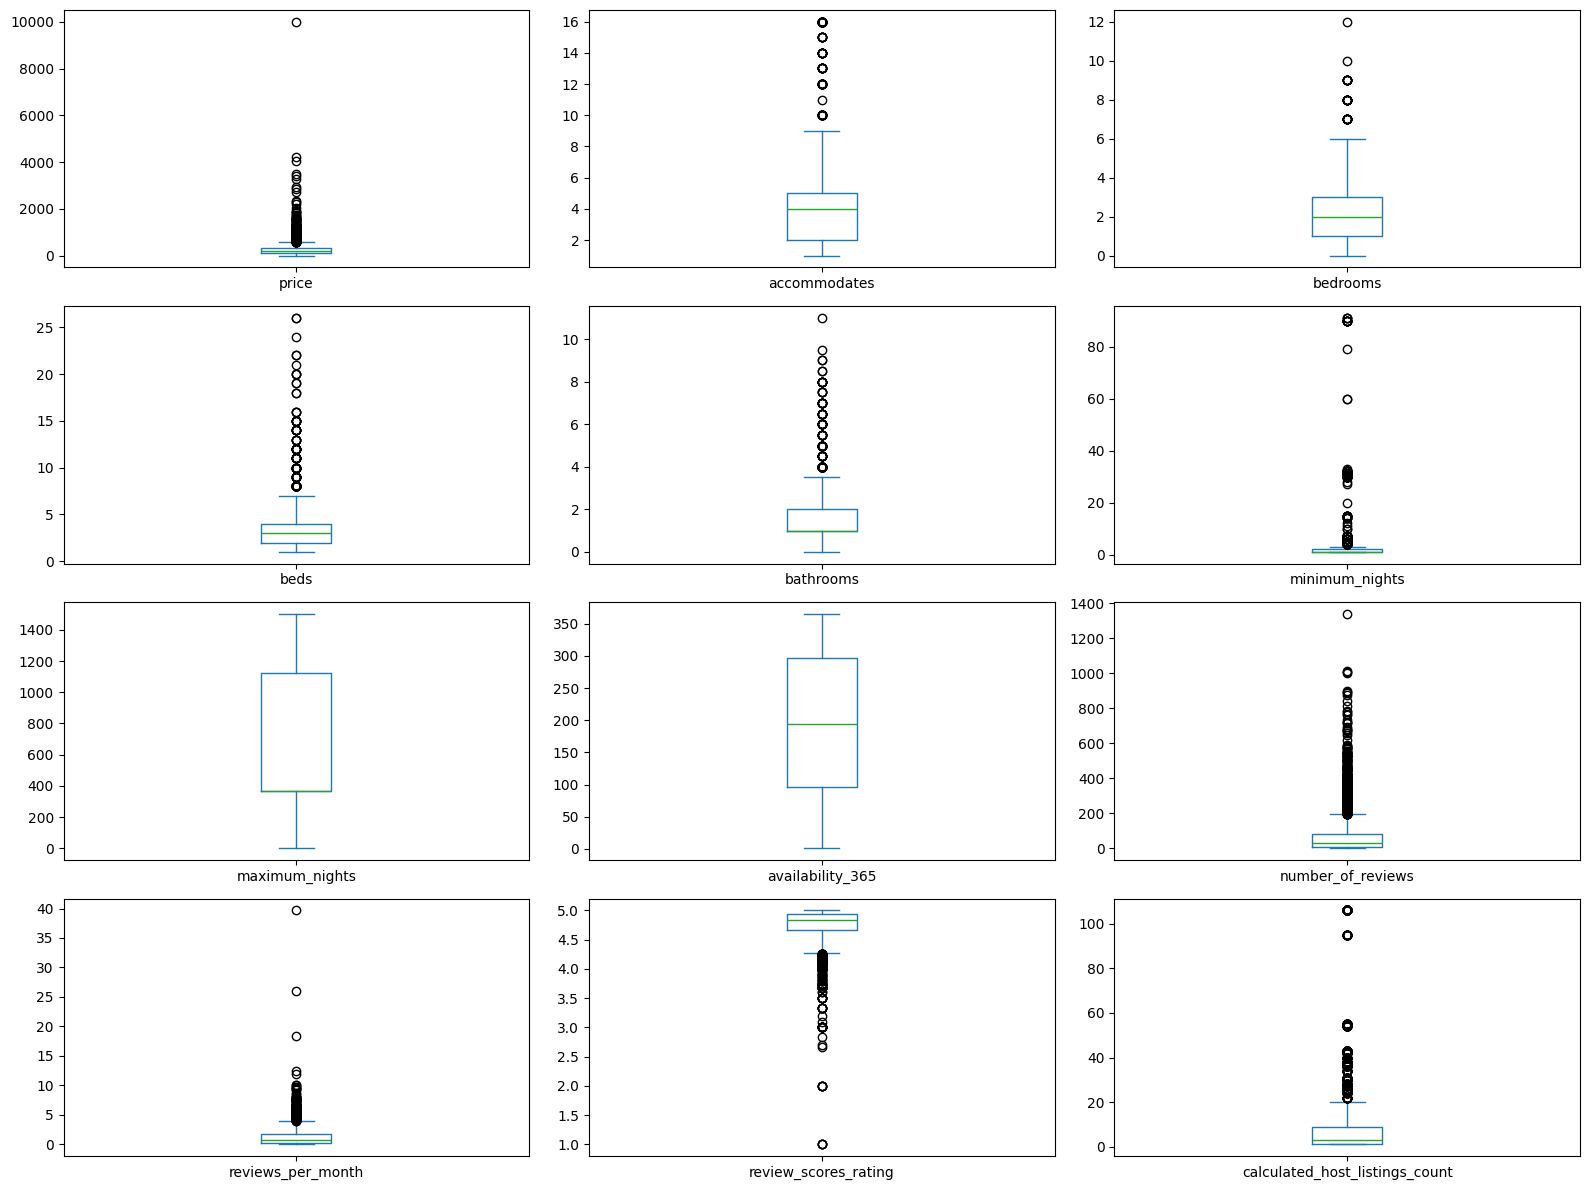

In [50]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 3), figsize=(16, 12))
plt.tight_layout()
plt.show()

### 8.5 Efecto de la corrección de tamaño: mejora real, aunque de una sola fila

In [51]:
size_vars = ["accommodates", "bedrooms", "bathrooms", "beds"]
df[size_vars].corrwith(df["price"]).round(4)

accommodates    0.4007
bedrooms        0.4001
bathrooms       0.3765
beds            0.3486
dtype: float64

Corregir esta única fila sube `bedrooms` de 0.3846 a 0.4001 y `bathrooms` de 0.3549 a 0.3765 en Pearson — una mejora más visible que en Sevilla (donde apenas se movía), porque aquí las tres variables estaban contaminadas a la vez en el mismo registro.

### 8.6 Conclusión y tratamiento

Se corrige la única fila de error de captura (sección 8.3). No se descarta ninguna fila de la cola alta de precio: los valores extremos tienen una explicación de mercado (evento deportivo, precio disuasorio), no son errores.

## 9. Agrupaciones

#### `neighbourhood_group_cleansed` (provincia) / `room_type` (repaso rápido)

In [52]:
df.groupby("neighbourhood_group_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False).round(1)

,count,mean,median
neighbourhood_group_cleansed,,,
Guipúzcoa,2221,337.3,266.5
Vizcaya,3045,220.9,172.0
Álava,404,194.6,146.6


Guipúzcoa encabeza con claridad (mediana 266€), muy por delante de Vizcaya (172€) y Álava (147€) — la provincia de Donostia/San Sebastián es sistemáticamente la más cara, no solo por su capital.

In [53]:
df.groupby("neighbourhood_cleansed")["price"].agg(["count", "mean", "median"]).loc[["Donostia-San Sebastián", "Bilbao", "Vitoria-Gasteiz"]].round(1)

,count,mean,median
neighbourhood_cleansed,,,
Donostia-San Sebastián,1410,387.4,331.1
Bilbao,1492,209.4,168.0
Vitoria-Gasteiz,164,144.3,132.5


El hallazgo más llamativo del dataset: **Donostia-San Sebastián (mediana 331€) casi duplica a Bilbao (168€)**, pese a tener un volumen de anuncios prácticamente idéntico (1410 vs. 1492). Y Vitoria-Gasteiz, la capital autonómica, es la más barata de las tres grandes (132.5€) — ser capital política no implica ser destino turístico caro, al revés que en Madrid.

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

In [54]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
0.0,1,99.00
1.0,2326,135.00
2.0,1803,218.50
3.0,1054,268.00
4.0,314,379.75
5.0,77,492.00
6.0,59,584.00
7.0,13,732.67
8.0,13,760.00


Relación creciente y monótona hasta 6 dormitorios: 1 → 135€, 2 → 218.5€, 3 → 268€, 4 → 379.8€, 5 → 492€, 6 → 584€. A partir de 7 la muestra ya es pequeña (13 anuncios o menos).

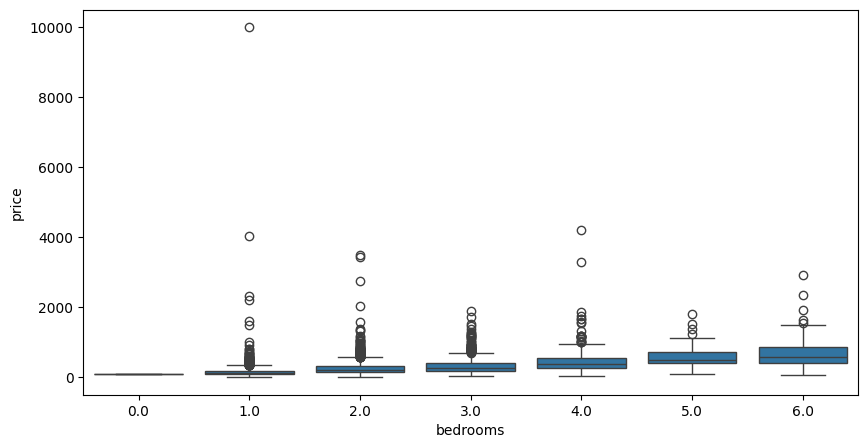

In [55]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price")
plt.show()

### 9.2 Calidad: `review_scores_rating`

In [56]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(0.07416217790453085), np.float64(0.1724379500306657))

Pearson casi nulo (0.074), Spearman algo más alto (0.172) pero sigue siendo débil: la nota media apenas explica el precio, patrón compartido con el resto de ciudades.

### 9.3 `has_license`

In [57]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,606,243.288993,151.00
True,5064,267.213079,201.26


Diferencia real y en la dirección esperada: 201€ de mediana con licencia frente a 151€ sin ella — más marcada que en Sevilla, donde la diferencia era mínima e incluso invertida.

### 9.4 `host_is_superhost`

In [58]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,3349,247.511493,185.0
True,2321,289.394300,217.0


Diferencia moderada (mediana 217€ con Superhost vs. 185€ sin él): podría reflejar que los Superhost tienden a gestionar alojamientos de más categoría, no necesariamente un efecto causal del sello en sí.

### 9.5 `property_type` (más granular que `room_type`)

In [59]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].agg(["count", "median"]).sort_values("median", ascending=False)

,count,median
property_type,,
Entire cottage,100,399.75
Entire home,307,310.00
Entire rental unit,3251,227.00
Entire serviced apartment,88,224.00
Entire condo,100,211.88
Room in hotel,195,148.50
Private room in hostel,93,129.00
Private room in bed and breakfast,88,124.50
Private room in home,215,98.50


`Entire cottage` encabeza (399.8€ de mediana) — el turismo rural/agroturismo vasco (caseríos, cottages) se paga más caro que el piso urbano estándar (`Entire rental unit`, 227€), un patrón propio de Euskadi que no aparece así en las ciudades puramente urbanas.

## 10. Correlación y visualización

### 10.1 Correlación con `price`

In [60]:
corr_vars = num_vars[1:] + ["estimated_revenue_l365d", "has_license", "host_is_superhost"]
df[corr_vars + ["price"]].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.400730
bedrooms                          0.400136
bathrooms                         0.376452
beds                              0.348585
estimated_revenue_l365d           0.323300
calculated_host_listings_count    0.159788
review_scores_rating              0.074162
availability_365                  0.059091
maximum_nights                    0.057732
has_license                       0.026769
number_of_reviews                -0.028766
reviews_per_month                -0.071207
minimum_nights                   -0.072081
Name: price, dtype: float64

`accommodates` (0.40) encabeza, seguido muy de cerca de `bedrooms` (0.40), y algo más atrás `bathrooms` (0.38) y `beds` (0.35) — el tamaño manda, igual que en las otras cinco ciudades.

In [61]:
df[corr_vars + ["price"]].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.576549
bedrooms                          0.550363
beds                              0.510010
bathrooms                         0.426049
estimated_revenue_l365d           0.318136
review_scores_rating              0.172438
has_license                       0.135507
maximum_nights                    0.118957
minimum_nights                    0.064816
number_of_reviews                 0.055237
availability_365                  0.000879
calculated_host_listings_count    0.000668
reviews_per_month                -0.024847
Name: price, dtype: float64

Con Spearman sube con claridad: `accommodates` a **0.58**, `bedrooms` a 0.55, `beds` a 0.51 — la cola larga de `price` (asimetría 11.2) sigue penalizando a Pearson incluso sin artefactos que limpiar.

### 10.2 Heatmap

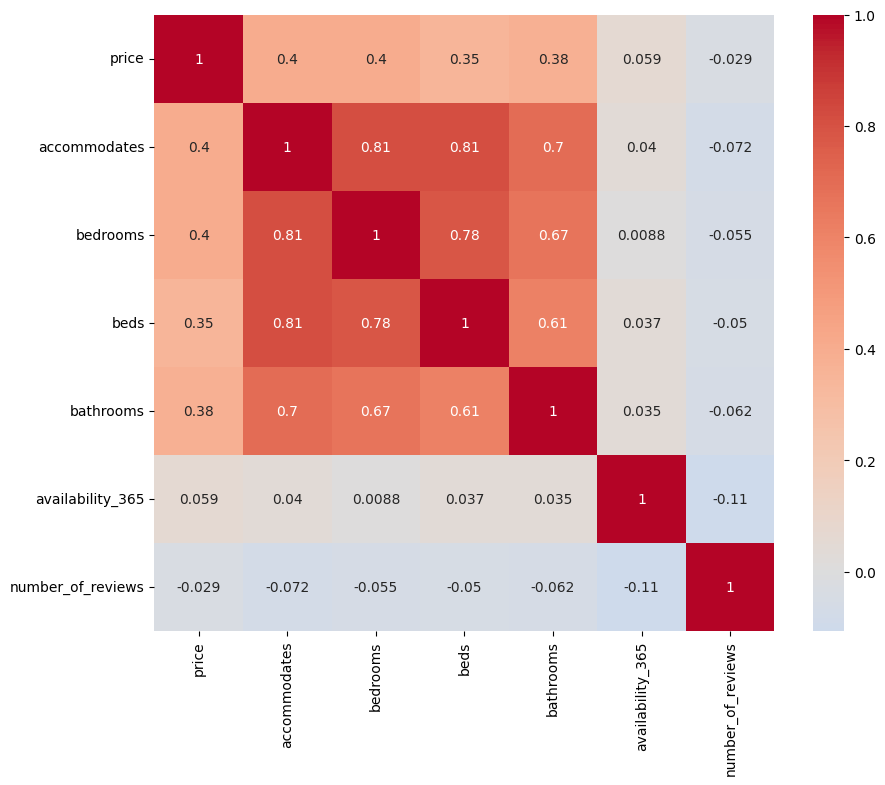

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[["price", "accommodates", "bedrooms", "beds", "bathrooms", "availability_365", "number_of_reviews"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

`accommodates`/`bedrooms`/`beds`/`bathrooms` muy correlacionadas entre sí (miden aspectos del mismo tamaño físico): vigilar multicolinealidad en un modelo lineal.

### 10.3 Pairplot

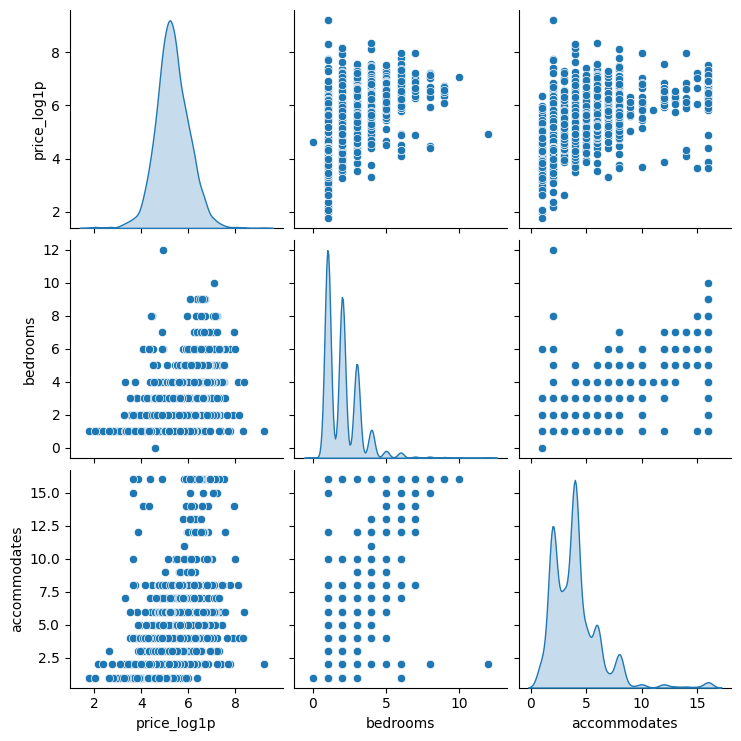

In [63]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price_log1p"] = np.log1p(pairplot_data["price"])
sns.pairplot(pairplot_data[["price_log1p", "bedrooms", "accommodates"]], diag_kind="kde")
plt.show()

Se ve la relación creciente entre `price_log1p` y ambas variables, con dispersión notable incluso a igualdad de tamaño — coherente con la historia de la sección 8.2 (evento deportivo, precio disuasorio) inflando puntos concretos fuera de la tendencia.

## 11. Análisis geográfico

### 11.1 Rango de coordenadas

In [64]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,42.48764,-3.441144
max,43.44149,-1.757010


Rango mucho más amplio que en cualquier ciudad anterior (lat 42.49-43.44, long -3.44 a -1.76): son ~105km de norte a sur y ~140km de este a oeste, todo Euskadi y no una sola ciudad.

### 11.2 Distribución espacial por provincia

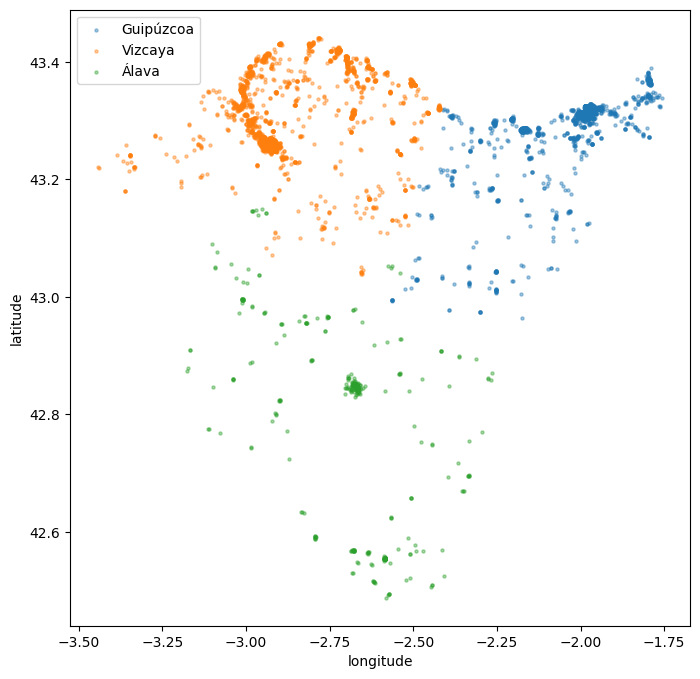

In [65]:
plt.figure(figsize=(8, 8))
for prov, color in zip(df["neighbourhood_group_cleansed"].unique(), ["tab:blue", "tab:orange", "tab:green"]):
    sub = df[df["neighbourhood_group_cleansed"] == prov]
    plt.scatter(sub["longitude"], sub["latitude"], s=5, alpha=0.4, label=prov, color=color)
plt.legend()
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

Las 3 provincias forman regiones geográficas compactas y bien separadas (Álava al sur, Vizcaya al oeste-centro, Guipúzcoa al este), confirmando que `neighbourhood_group_cleansed` captura una estructura territorial real, no una etiqueta administrativa arbitraria.

### 11.3 Precio en el mapa

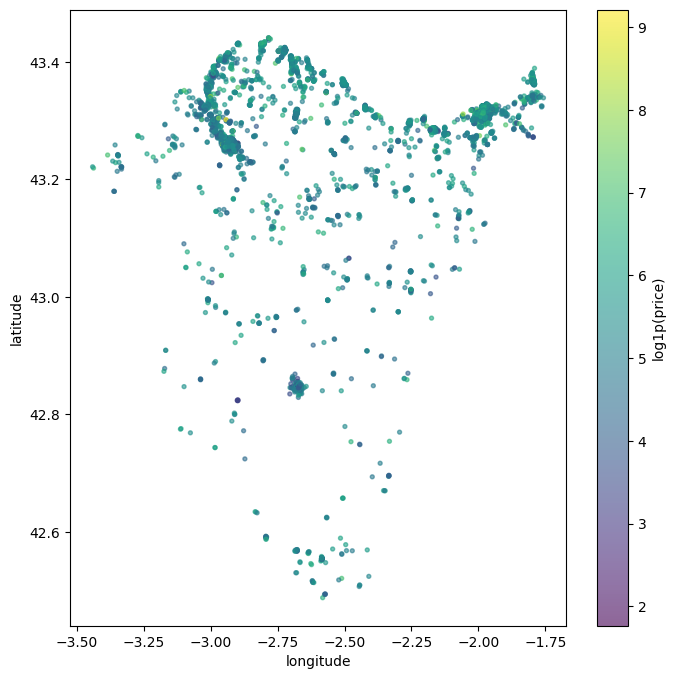

In [66]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(df["longitude"], df["latitude"], c=np.log1p(df["price"]), s=8, cmap="viridis", alpha=0.6)
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

Se distingue una franja costera más cara (de Hondarribia a Getxo, pasando por Donostia) frente a un interior más barato, sobre todo hacia Álava — coherente con el ranking de la sección 9.

### 11.4 ¿Dónde están los anuncios grandes?

In [67]:
df.loc[df["bedrooms"] >= 6, "neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Vizcaya      46
Guipúzcoa    31
Álava        18
Name: count, dtype: int64

De los 95 anuncios con 6+ dormitorios, 46 (48.4%) están en Vizcaya, 31 (32.6%) en Guipúzcoa y 18 (18.9%) en Álava — reparto bastante proporcional al tamaño de cada provincia, sin una concentración extrema como la de Sevilla en `Casco Antiguo`.

### 11.5 Densidad de anuncios cercanos

In [68]:
from sklearn.neighbors import BallTree

coords = np.radians(df[["latitude", "longitude"]].values)
tree = BallTree(coords, metric="haversine")
radius = 150 / 6_371_000
n_nearby_150m = tree.query_radius(coords, r=radius, count_only=True) - 1
pd.Series(n_nearby_150m).describe()

count    5670.000000
mean       19.181658
std        24.972671
min         0.000000
25%         2.000000
50%         8.000000
75%        29.000000
max       137.000000
dtype: float64

Se comprueba la correlación con `price` para valorar si merece la pena como candidata a feature.

In [69]:
pd.Series(n_nearby_150m, index=df.index, name="n_nearby_150m").corr(df["price"])

np.float64(0.08476619831411436)

Correlación débil pero positiva (0.08): más densidad de anuncios cerca se asocia a zonas turísticas caras (centro de Donostia, Casco Viejo de Bilbao), no a un efecto de saturación de precios.

## 12. Amenities

### 12.1 Formato y cardinalidad

In [70]:
import ast

df["amenities"].isnull().sum()

np.int64(0)

In [71]:
parsed_amenities = df["amenities"].apply(ast.literal_eval)
n_amenities = parsed_amenities.apply(len)
n_amenities.describe()

count    5670.000000
mean       32.048501
std        15.766541
min         1.000000
25%        20.000000
50%        33.000000
75%        44.000000
max        93.000000
Name: amenities, dtype: float64

Sin nulos, media de ~32.0 amenities por anuncio (mediana 33), de 1 a 93. Se comprueba cuántos valores distintos de amenity existen en total y cuántos son casi anecdóticos.

In [72]:
amenity_counter = Counter()
for lst in parsed_amenities:
    amenity_counter.update(lst)
len(amenity_counter)

1711

1711 valores distintos, y más de la mitad (57.6%) aparece en un único anuncio: la misma cola larguísima de texto libre ya vista en las otras ciudades (marcas de electrodomésticos, nombres de calles en el campo de wifi, etc.).

### 12.2 Top amenities y el problema de la fragmentación

In [73]:
pd.Series(dict(amenity_counter.most_common(12)), name="n_anuncios")

Wifi                     5056
Kitchen                  4738
Hot water                4584
Hair dryer               4567
Hangers                  4197
Bed linens               4112
Dishes and silverware    4110
Microwave                4006
TV                       3997
Essentials               3952
Fire extinguisher        3809
Refrigerator             3783
Name: n_anuncios, dtype: int64

Las más comunes (`Wifi` 89.2%, `Kitchen` 83.6%, `Hot water` 80.8%...) están casi universalizadas, con poca variación explotable directamente.

In [74]:
ac_variants = [k for k in amenity_counter if "air condition" in k.lower()]
ac_variants

['Air conditioning', 'Portable air conditioning', 'Central air conditioning']

Varias variantes distintas para "tiene aire acondicionado", igual que en las otras ciudades. Hace falta agrupar por palabra clave, no por texto exacto.

### 12.3 Candidatas para feature engineering

In [75]:
def has_any(lst, keywords, exclude=None):
    for item in lst:
        item_l = item.lower()
        if exclude and any(ex in item_l for ex in exclude):
            continue
        if any(kw in item_l for kw in keywords):
            return True
    return False


candidates = pd.DataFrame({
    "has_ac": parsed_amenities.apply(lambda l: has_any(l, ["air condition"])),
    "has_pool": parsed_amenities.apply(lambda l: has_any(l, ["pool"])),
    "has_dishwasher": parsed_amenities.apply(lambda l: has_any(l, ["dishwasher"])),
    "has_sea_view": parsed_amenities.apply(lambda l: has_any(l, ["sea view", "beach view", "ocean view"])),
})
candidates["price"] = df["price"]

for c in ["has_ac", "has_pool", "has_dishwasher", "has_sea_view"]:
    prevalence = candidates[c].mean()
    corr = candidates[c].astype(int).corr(candidates["price"])
    print(f"{c}: prevalencia {prevalence:.1%}, corr con price {corr:.3f}")


has_ac: prevalencia 16.8%, corr con price 0.057
has_pool: prevalencia 6.0%, corr con price 0.113
has_dishwasher: prevalencia 49.7%, corr con price 0.197
has_sea_view: prevalencia 5.1%, corr con price 0.097


`has_dishwasher` destaca con fuerza: **49.7% de prevalencia** (mucho más alto que en cualquier ciudad anterior) y la correlación más alta de las cuatro (0.197) — coherente con que buena parte del parque es vivienda vacacional bien equipada, no piso turístico urbano básico. `has_ac` es bajo (16.8%) y con poca correlación (0.057), esperable en un clima atlántico donde el aire acondicionado no es tan necesario. `has_sea_view`, nueva variable (como en Mallorca), aparece en el 5.1% de los anuncios — mucho menos frecuente que en la isla (12%), pero con correlación similar (0.097) al ser un litoral más acotado (Donostia, Getxo, Zarautz, Hondarribia).

## 13. Conclusiones

### Limpieza aplicada

De las 6248 filas y 90 columnas originales quedan **5670 filas × 78 columnas**:
- 12 columnas 100% vacías eliminadas (las mismas que en las otras cinco ciudades).
- Mojibake corregido en `neighbourhood_cleansed`/`neighbourhood_group_cleansed` (20 de 207 municipios afectados).
- `bathrooms` recuperado desde `bathrooms_text` (939 de 971, incluyendo 12 casos de "half-bath" sin dígito); 20 filas sin ningún dato de baños se resuelven junto con `bedrooms`/`beds`.
- Reviews sin datos por no tener reviews todavía: `reviews_per_month` imputado a 0, el resto se deja como `NaN`/`NaT`.
- `license` convertido en flag `has_license` (88.19% con licencia), y el texto imputado a `"Sin licencia"`.
- Filas sin `price` descartadas (572, 9.15%).
- Columnas de bajo volumen (host/estancia, ~0.07-0.11%) descartadas (6 filas).
- `bedrooms`/`beds`/`bathrooms` imputados con la mediana por `room_type`.
- `has_availability` eliminada (100% constante tras la limpieza de filas anterior).
- Sin duplicados de fila completa ni de `id`; 62 "duplicados lógicos" (mismo alojamiento, distinta habitación) son anuncios reales distintos.
- 1 fila con `bedrooms`/`beds`/`bathrooms` de captura errónea corregida (sección 8.3) — a diferencia de Sevilla, aquí las tres variables estaban contaminadas a la vez.
- **Ninguna fila descartada por precio-artefacto** (sección 8.2): la cola alta tiene explicación de mercado real (final de la Europa League en San Mamés, precio disuasorio puntual), no es un error.

### Variables nuevas

- `has_license`: flag booleano derivado de `license`.
- `has_ac`, `has_pool`, `has_dishwasher`, `has_sea_view`: flags derivados de `amenities` por palabra clave.

### El hallazgo principal: Donostia y Bilbao son dos mercados de precio muy distintos, con volumen casi idéntico

- Donostia-San Sebastián (mediana 331€) casi duplica a Bilbao (168€), pese a tener casi el mismo número de anuncios (1410 vs. 1492).
- Vitoria-Gasteiz, la capital autonómica, es la más barata de las tres grandes (132.5€ de mediana): ser capital política no implica ser destino turístico caro.
- `accommodates` (Spearman 0.58), `bedrooms` (0.55) y `beds` (0.51) son las variables más correlacionadas con `price`, el mismo patrón de las otras cinco ciudades.
- `has_dishwasher` (49.7% de prevalencia, corr. 0.197) es la amenity candidata más fuerte de las cuatro, mucho más presente que en cualquier ciudad anterior — parque de vivienda vacacional bien equipado.
- `Entire cottage` (agroturismo/caserío) es el `property_type` más caro por mediana (399.8€), por delante del piso urbano estándar (227€) — un patrón de turismo rural que no aparece así en las ciudades puramente urbanas.

### Un fenómeno propio: la final de la Europa League en San Mamés

12 anuncios en Bilbao renombraron explícitamente su anuncio ("Final Europa League", "UEFA Final"...) para la semana del evento, con una mediana de precio (405€) más del doble de la general (196€) y picos de hasta 4.222€/noche. No es un error de captura ni un artefacto: es un pico de demanda real, puntual y verificable por el propio nombre del anuncio — un tipo de hallazgo que no había aparecido en ninguna de las otras cinco ciudades.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `accommodates`/`bedrooms`/`beds`/`bathrooms` correlacionadas entre sí: vigilar multicolinealidad en un modelo lineal.
- `property_type` (61 categorías, la cifra más alta de las seis ciudades) necesitará agrupar las categorías raras con más agresividad que en ninguna otra ciudad.
- Las familias redundantes de `minimum_nights`/`maximum_nights` y `availability` no se han simplificado, solo diagnosticado.
- Candidatas a log-transform: `price` (asimetría todavía alta) y las variables de reviews.
- Jerarquía geográfica de dos niveles (`neighbourhood_group_cleansed`=provincia, `neighbourhood_cleansed`=municipio), como Sevilla/Valencia — no plana como Mallorca.
- Un posible punto de referencia para `distance_to_center_km` no es evidente: hay tres polos (Bilbao, Donostia, Vitoria-Gasteiz) en vez de un único centro. Se decide en el notebook de feature engineering.

## 14. Exportar dataset limpio

In [76]:
df.to_csv(f"{PROJECT_DIR}/data/processed/euskadi/listings_full_clean.csv", index=False)
df.shape

(5670, 78)